# Movie Ratings Prediction & Insights Project
## Phase 1: Data Acquisition & Cleaning

**Objective:** Load the dataset, handle missing values, remove duplicates, clean inconsistent formats, and parse complex columns to prepare a high-quality dataset for analysis.

In [97]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datetime import datetime
from scipy import stats

# Set display options
1import warnings
warnings.filterwarnings('ignore')

### Task 1.1: Dataset Selection & Loading

In [98]:
# Load the dataset
file_path = 'archive (6)/movies.csv'
movies = pd.read_csv(file_path)

# ADD THIS LINE - Create 'rating' column from 'vote_average'
movies['rating'] = movies['vote_average']

# Initial Exploration
print(f"Dataset Shape: {movies.shape}")
print("\nFirst 3 rows:")
display(movies.head(3))
print("\nData Info:")
movies.info()

Dataset Shape: (4803, 25)

First 3 rows:


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director,rating
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron,7.2
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski,6.9
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes,6.3



Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_la

### Task 1.2: Missing Value Handling

In [99]:
# Check missing values
missing = movies.isnull().sum()
missing_percent = (movies.isnull().sum() / len(movies)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
print(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False))

# Strategy implementation
# 1. Drop columns with excessive missing data (>50%) if any, or irrelevant for current analysis
# Note: 'homepage' and 'tagline' often have high missingness but might be kept or dropped. 
# For this project, we focus on numerical/categorical analysis, so we might drop them later or ignore.

# 2. Handle Budget & Revenue 0 values (often represented as 0 instead of NaN in TMDB)
# We will treat 0 as NaN for imputation purposes if we need strict cleaning, 
# or filter them out for specific ROI analyses.

# 3. Drop rows with missing critical information (e.g., release_date, title)
movies.dropna(subset=['release_date', 'title'], inplace=True)

print(f"\nShape after dropping rows with missing essential info: {movies.shape}")

              Missing Count  Missing %
homepage               3091  64.355611
tagline                 844  17.572351
keywords                412   8.577972
cast                     43   0.895274
director                 30   0.624610
genres                   28   0.582969
overview                  3   0.062461
runtime                   2   0.041641
release_date              1   0.020820

Shape after dropping rows with missing essential info: (4802, 25)


### Task 1.3: Duplicate Removal

In [100]:
duplicates = movies.duplicated().sum()
print(f"Full Duplicates: {duplicates}")

# Check for title + release_date duplicates
subset_duplicates = movies.duplicated(subset=['title', 'release_date']).sum()
print(f"Title + Date Duplicates: {subset_duplicates}")

# Drop duplicates
movies.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {movies.shape}")

Full Duplicates: 0
Title + Date Duplicates: 0
Shape after removing duplicates: (4802, 25)


### Task 1.4: Budget & Revenue Cleaning
Ensure budget and revenue are numeric and handle 0 values.

In [101]:
# TMDB dataset 'budget' and 'revenue' are usually numeric, but we ensure it.
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce')

# Report on 0 values
zero_budget = (movies['budget'] == 0).sum()
zero_revenue = (movies['revenue'] == 0).sum()
print(f"Entries with 0 Budget: {zero_budget}")
print(f"Entries with 0 Revenue: {zero_revenue}")

# For this analysis, we will replace 0 with NaN to calculate medians, 
# then we can decide to impute or drop for specific ROI analysis.
# Filling 0s with NaN for now to see distribution
movies['budget_clean'] = movies['budget'].replace(0, np.nan)
movies['revenue_clean'] = movies['revenue'].replace(0, np.nan)

# Impute with median (grouped by something if possible, or global median)
# Simple Median Imputation for now as per requirements
budget_median = movies['budget_clean'].median()
revenue_median = movies['revenue_clean'].median()

print(f"Median Budget (ignoring 0): {budget_median}")
print(f"Median Revenue (ignoring 0): {revenue_median}")

# Filling NaNs (formerly 0s) with median
movies['budget_filled'] = movies['budget_clean'].fillna(budget_median)
movies['revenue_filled'] = movies['revenue_clean'].fillna(revenue_median)

# Use the filled columns for main analysis, or keep original if we want to drop them for ROI
# Requirements: "Fill with median if 5-30% missing" (or 0s in this case)
# We will update the main columns
movies['budget'] = movies['budget_filled']
movies['revenue'] = movies['revenue_filled']

# Drop temp columns
movies.drop(columns=['budget_clean', 'revenue_clean', 'budget_filled', 'revenue_filled'], inplace=True)

Entries with 0 Budget: 1036
Entries with 0 Revenue: 1426
Median Budget (ignoring 0): 23000000.0
Median Revenue (ignoring 0): 51751835.0


### Task 1.5: Date Cleaning & Year Extraction

In [102]:
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year
movies['release_month'] = movies['release_date'].dt.month

# Check for invalid years
print(f"Year Range: {movies['release_year'].min()} - {movies['release_year'].max()}")

# Drop rows where year could not be extracted
movies.dropna(subset=['release_year'], inplace=True)
movies['release_year'] = movies['release_year'].astype(int)

Year Range: 1916 - 2017


### Task 1.7: Genre Parsing
The genres are stored as a JSON string (list of dicts). We need to extract the names.

In [103]:
def parse_json_column(x, key='name'):
    try:
        if pd.isna(x):
            return []
        if isinstance(x, str):
            # Handle the format: "Action Adventure Fantasy"
            if '[' not in x and '{' not in x:
                return x.split()
            data = ast.literal_eval(x)
        else:
            data = x
        if isinstance(data, list):
            return [item[key] for item in data if isinstance(item, dict)]
        return []
    except:
        return []

# Extract Genre list
movies['genre_list'] = movies['genres'].apply(parse_json_column)

# Extract Primary Genre
movies['primary_genre'] = movies['genre_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# Check result
print(movies[['genres', 'genre_list', 'primary_genre']].head())

                                     genres  \
0  Action Adventure Fantasy Science Fiction   
1                  Adventure Fantasy Action   
2                    Action Adventure Crime   
3               Action Crime Drama Thriller   
4          Action Adventure Science Fiction   

                                       genre_list primary_genre  
0  [Action, Adventure, Fantasy, Science, Fiction]        Action  
1                    [Adventure, Fantasy, Action]     Adventure  
2                      [Action, Adventure, Crime]        Action  
3                [Action, Crime, Drama, Thriller]        Action  
4           [Action, Adventure, Science, Fiction]        Action  


### Task 1.6: Outlier Detection
Visualizing distribution of Budget and Revenue.

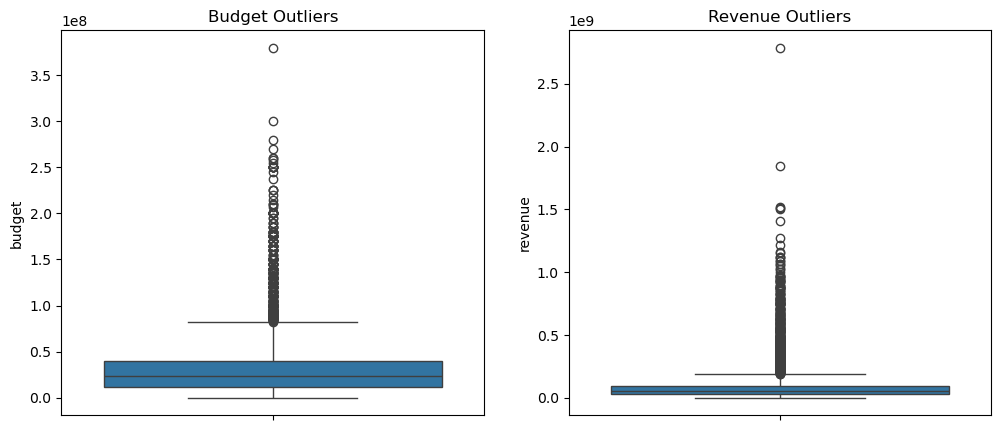

Budget Outliers (Z > 3): 145


In [104]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=movies['budget'])
plt.title('Budget Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(y=movies['revenue'])
plt.title('Revenue Outliers')
plt.show()

# Calculate Z-scores for info (not dropping automatically)
z_scores_budget = np.abs(stats.zscore(movies['budget']))
print(f"Budget Outliers (Z > 3): {(z_scores_budget > 3).sum()}")

### Task 1.8: Save Cleaned Dataset

In [105]:
output_path = 'movies_cleaned.csv'
movies.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

# Summary
print(f"Final Dataset Shape: {movies.shape}")

Cleaned dataset saved to: movies_cleaned.csv
Final Dataset Shape: (4802, 29)


## Phase 2: Exploratory Data Analysis (EDA)

### Task 2.1: Univariate Analysis - Numerical

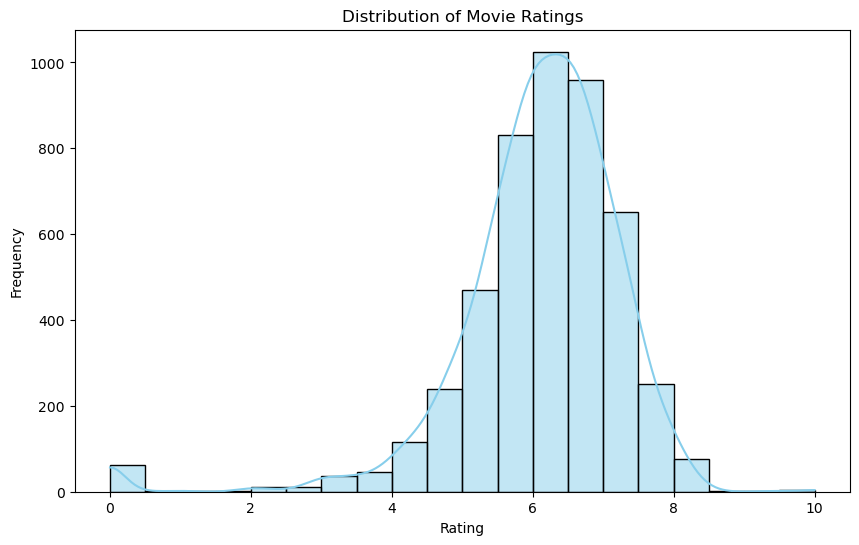

Mean Rating: 6.09
Median Rating: 6.20
Rating Skewness: -1.95


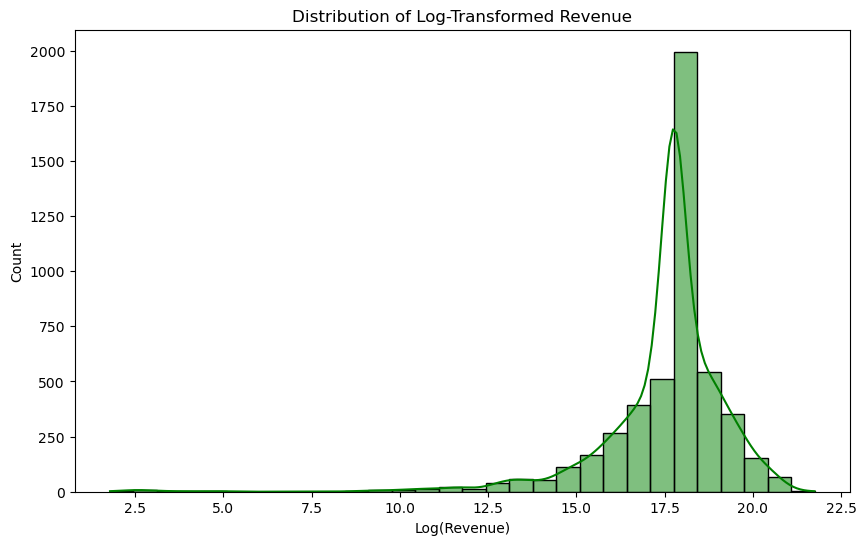

In [106]:
# Rating Distribution
plt.figure(figsize=(10, 6))
sns.histplot(movies['rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.savefig('revenue_distribution.png')
plt.show()

print(f"Mean Rating: {movies['rating'].mean():.2f}")
print(f"Median Rating: {movies['rating'].median():.2f}")
print(f"Rating Skewness: {movies['rating'].skew():.2f}")

# Revenue Distribution (Log Scale)
plt.figure(figsize=(10, 6))
# Handle 0 or negative values for log plot safely
revenue_to_plot = movies[movies['revenue'] > 0]['revenue']
sns.histplot(np.log1p(revenue_to_plot), bins=30, kde=True, color='green')
plt.title('Distribution of Log-Transformed Revenue')
plt.xlabel('Log(Revenue)')
plt.show()

### Task 2.2: Univariate Analysis - Categorical

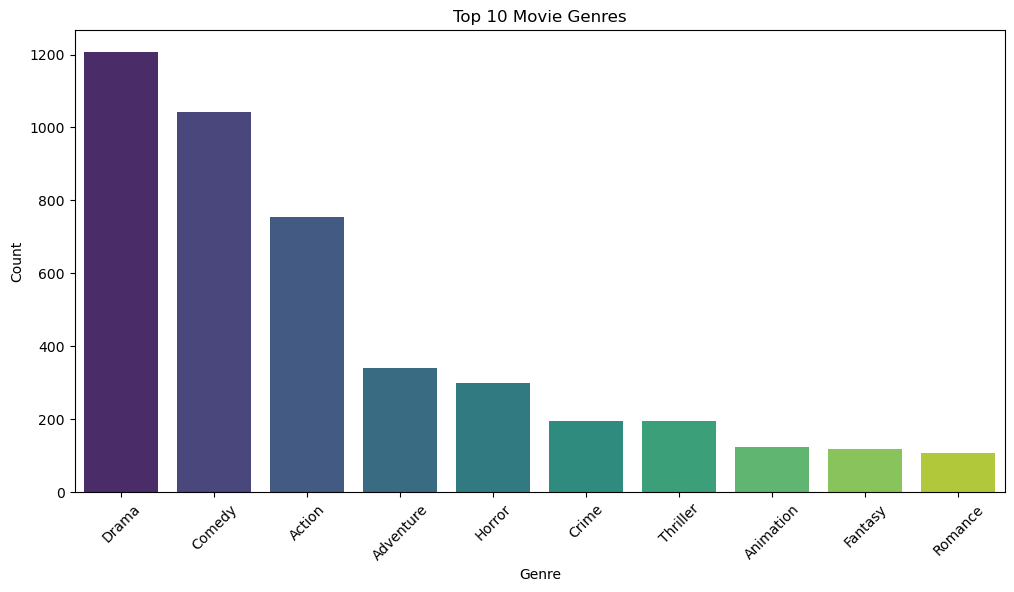

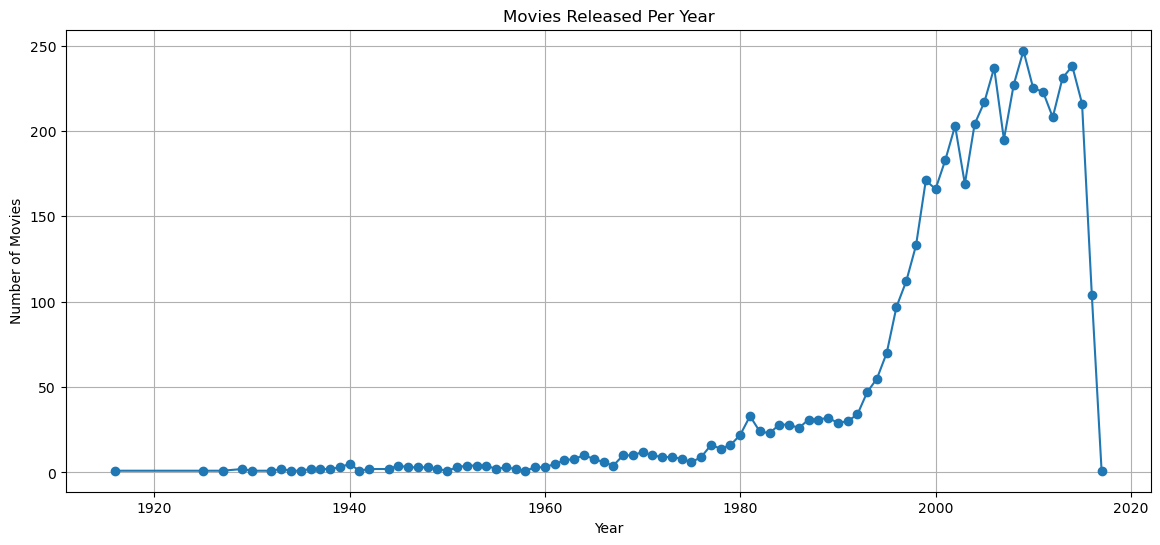

In [107]:
# Genre Frequency
plt.figure(figsize=(12, 6))
top_genres = movies['primary_genre'].value_counts().head(10)
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('genre_frequency.png')
plt.show()

# Release Year Trend
plt.figure(figsize=(14, 6))
movies['release_year'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(True)
plt.show()

### Task 2.3: Bivariate Analysis

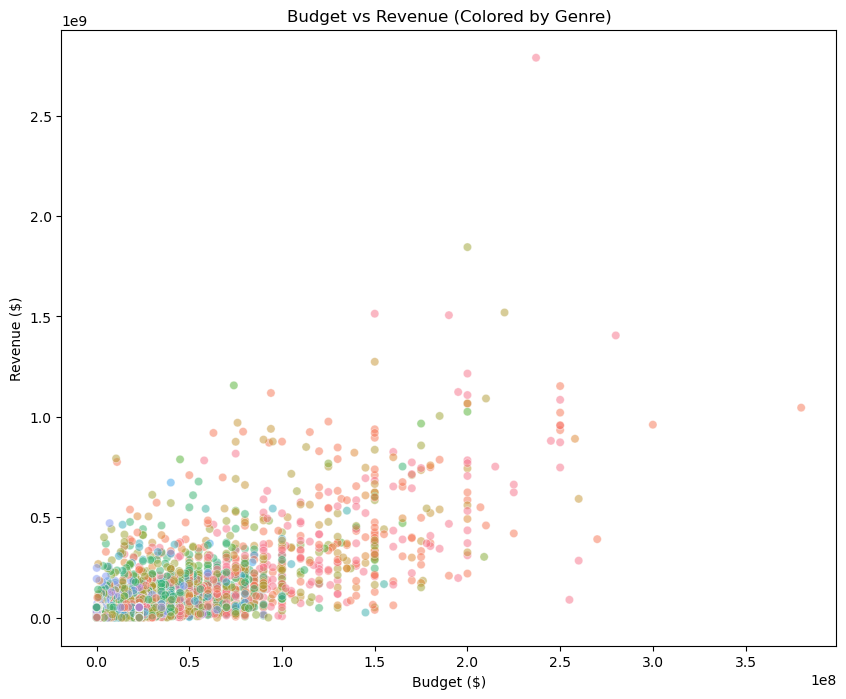

Correlation betwen Budget and Revenue: 0.709


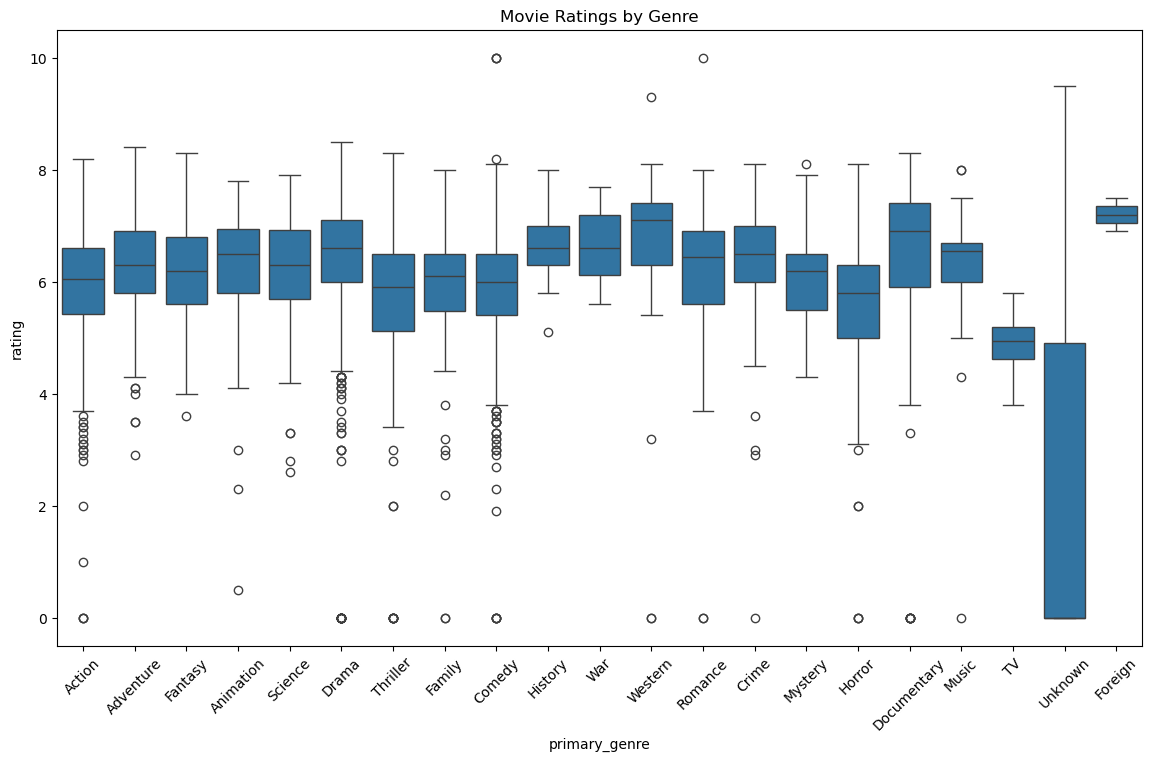

In [108]:
Bivariate# Budget vs Revenue
plt.figure(figsize=(10, 8))
sns.scatterplot(x='budget', y='revenue', hue='primary_genre', data=movies, alpha=0.5, legend=False)
plt.title('Budget vs Revenue (Colored by Genre)')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.savefig('genre_boxplot.png')
plt.show()

# Correlation
corr = movies['budget'].corr(movies['revenue'])
print(f"Correlation betwen Budget and Revenue: {corr:.3f}")

# Ratings by Genre (Box Plot)
plt.figure(figsize=(14, 8))
sns.boxplot(x='primary_genre', y='rating', data=movies)
plt.xticks(rotation=45)
plt.title('Movie Ratings by Genre')
plt.show()

### Task 2.4: Correlation Analysis

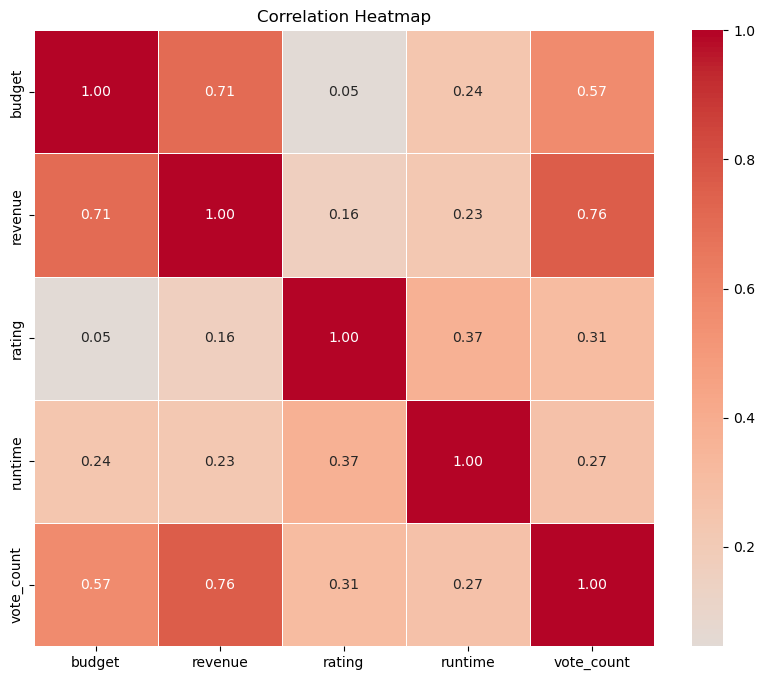

In [109]:
numerical_cols = ['budget', 'revenue', 'rating', 'runtime', 'vote_count']
corr_matrix = movies[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

### Task 2.5: Time-Based Analysis

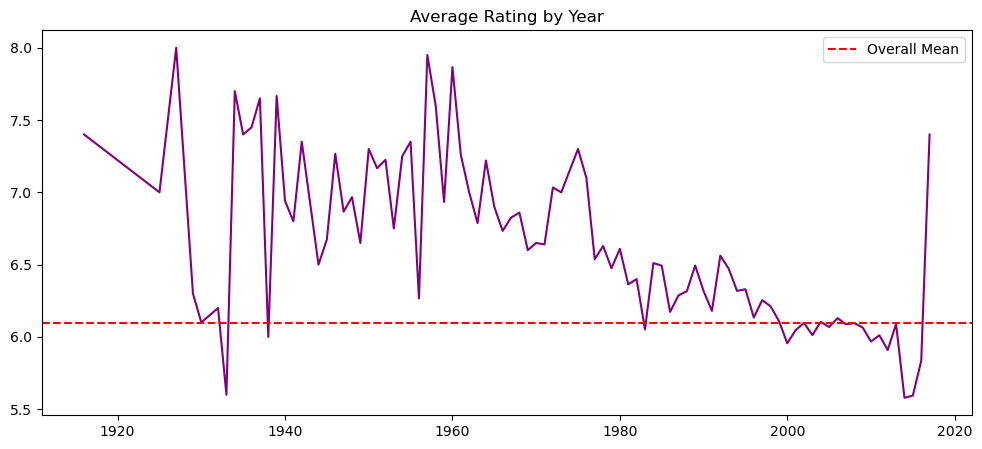

In [110]:
# Ratings Over Time
yearly_avg_rating = movies.groupby('release_year')['rating'].mean()
plt.figure(figsize=(12, 5))
plt.plot(yearly_avg_rating.index, yearly_avg_rating.values, color='purple')
plt.title('Average Rating by Year')
plt.axhline(y=movies['rating'].mean(), color='r', linestyle='--', label='Overall Mean')
plt.legend()
plt.show()

### Task 2.6: Advanced Visualizations

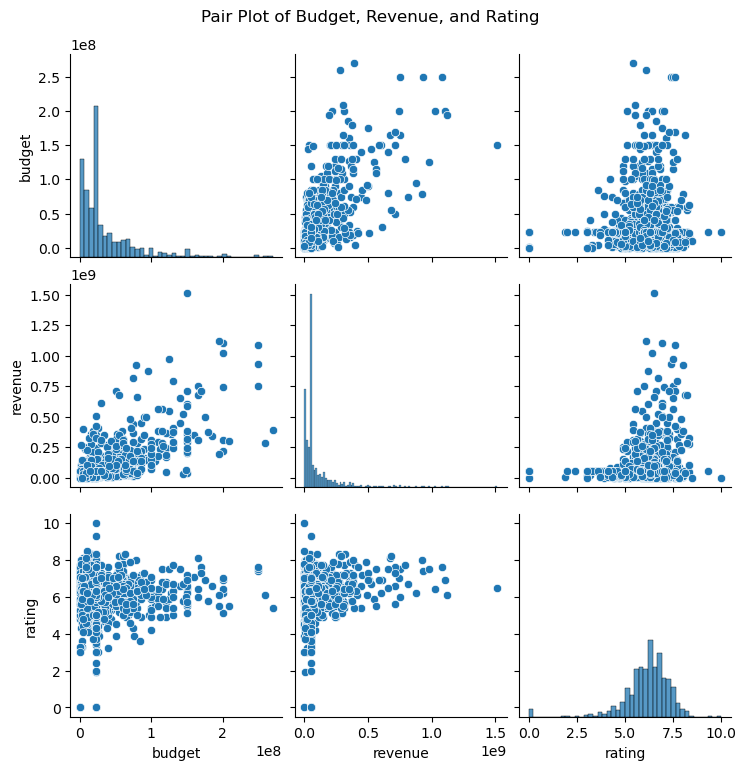

In [111]:
# Pair Plot for key features
selected_cols = ['budget', 'revenue', 'rating']
# Sample for speed if dataset is huge
sample_movies = movies.sample(min(1000, len(movies)))
sns.pairplot(sample_movies[selected_cols])
plt.suptitle('Pair Plot of Budget, Revenue, and Rating', y=1.02)
plt.show()

## Phase 3: Feature Engineering & Selection

### Task 3.1: Feature Creation

In [112]:
# Decade Feature
movies['decade'] = (movies['release_year'] // 10) * 10

# Budget-Revenue Ratio (ROI)
# Avoid division by zero by replacing 0 budget with NaN or a small number, 
# but we already filled 0s with median in Phase 1 (for 'budget' column).
movies['roi'] = (movies['revenue'] - movies['budget']) / movies['budget']
movies['is_profitable'] = (movies['revenue'] > movies['budget']).astype(int)

# Runtime Categories
bins = [0, 90, 120, 150, float('inf')]
labels = ['Short', 'Medium', 'Long', 'Very Long']
movies['runtime_category'] = pd.cut(movies['runtime'], bins=bins, labels=labels)

# Release Season
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
movies['release_season'] = movies['release_month'].apply(get_season)

# Log Transforms (for skewed features)
# Adding small constant to handle 0
movies['log_budget'] = np.log1p(movies['budget'])
movies['log_revenue'] = np.log1p(movies['revenue'])

print("New Features Created:", ['decade', 'roi', 'is_profitable', 'runtime_category', 'release_season', 'log_budget', 'log_revenue'])
movies[['title', 'decade', 'roi', 'release_season']].head()

New Features Created: ['decade', 'roi', 'is_profitable', 'runtime_category', 'release_season', 'log_budget', 'log_revenue']


,title,decade,roi,release_season
0,Avatar,2000,10.763566,Winter
1,Pirates of the Caribbean: At World's End,2000,2.203333,Spring
2,Spectre,2010,2.594590,Fall
3,The Dark Knight Rises,2010,3.339756,Summer
4,John Carter,2010,0.092843,Spring


### Task 3.2: Encoding Categorical Variables

In [113]:
# One-Hot Encoding for Genres
genre_dummies = pd.get_dummies(movies['primary_genre'], prefix='genre')
movies = pd.concat([movies, genre_dummies], axis=1)

# Label Encoding for Genre (useful for some models)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
movies['genre_encoded'] = le.fit_transform(movies['primary_genre'])

# Ordinal Encoding for Runtime Category
runtime_order = {'Short': 0, 'Medium': 1, 'Long': 2, 'Very Long': 3}
movies['runtime_ordinal'] = movies['runtime_category'].map(runtime_order)

# Binary Encoding (Season - Is Summer?)
movies['is_summer_release'] = movies['release_season'].apply(lambda x: 1 if x == 'Summer' else 0)

print("Encoding Complete.")

Encoding Complete.


### Task 3.3: Feature Scaling

In [114]:
from sklearn.preprocessing import StandardScaler

# Select numerical features for scaling
scale_cols = ['budget', 'revenue', 'runtime', 'vote_count', 'vote_average', 'roi']
# Handle infinite ROI if any (from 0 budget if not handled)
movies['roi'] = movies['roi'].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
movies_scaled = movies.copy()
movies_scaled[scale_cols] = scaler.fit_transform(movies[scale_cols].fillna(0))

print("Features Scaled:", scale_cols)

Features Scaled: ['budget', 'revenue', 'runtime', 'vote_count', 'vote_average', 'roi']


### Task 3.4: Filter Method - Correlation-Based Selection

In [115]:
# Target: Rating
target = 'rating'

# Calculate correlation of numerical features with target
numerical_features = movies.select_dtypes(include=[np.number]).columns.tolist()
# Remove target itself
if target in numerical_features: numerical_features.remove(target)

correlations = movies[numerical_features].corrwith(movies[target])
selected_filter = correlations[abs(correlations) > 0.1].index.tolist()

print("Top Correlations with Rating:")
print(correlations.sort_values(ascending=False).head(10))
print(f"\nSelected by Filter Method (>0.1): {selected_filter}")

Top Correlations with Rating:
vote_average     1.000000
runtime          0.371888
vote_count       0.313263
popularity       0.273990
revenue          0.162947
release_month    0.108011
is_profitable    0.060898
log_revenue      0.058588
budget           0.046028
log_budget       0.016193
dtype: float64

Selected by Filter Method (>0.1): ['index', 'id', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'release_year', 'release_month', 'decade']


### Task 3.5: Lasso Regression for Feature Selection

In [116]:
from sklearn.linear_model import Lasso

# Prepare X and y
# Drop non-numeric and target
X = movies[numerical_features].fillna(0)
y = movies[target]

# Standardize X for Lasso (important)
X_std = scaler.fit_transform(X)

lasso = Lasso(alpha=0.01) # Small alpha for some selection
lasso.fit(X_std, y)

lasso_selected = [f for f, c in zip(numerical_features, lasso.coef_) if abs(c) > 0.001]
print(f"Selected by Lasso: {lasso_selected}")
print("Coefficients:", dict(zip(lasso_selected, lasso.coef_[lasso.coef_ != 0])))

Selected by Lasso: ['vote_average']
Coefficients: {'vote_average': 1.181372163383077}


### Task 3.6: Recursive Feature Elimination (RFE)

In [117]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=10)
rfe.fit(X_std, y)

rfe_selected = [f for f, s in zip(numerical_features, rfe.support_) if s]
print(f"Selected by RFE (Top 10): {rfe_selected}")

ranking = pd.DataFrame({
    'Feature': numerical_features,
    'Rank': rfe.ranking_
}).sort_values('Rank')
print(ranking.head(10))

Selected by RFE (Top 10): ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'roi', 'log_budget', 'log_revenue', 'genre_encoded', 'is_summer_release']
              Feature  Rank
16  is_summer_release     1
1              budget     1
14        log_revenue     1
13         log_budget     1
4             revenue     1
5             runtime     1
6        vote_average     1
7          vote_count     1
15      genre_encoded     1
11                roi     1


### Task 3.7: Feature Selection Summary

In [118]:
summary = pd.DataFrame(index=numerical_features)
summary['Corr_Value'] = correlations
summary['Selected_Filter'] = summary.index.isin(selected_filter)
summary['Selected_Lasso'] = summary.index.isin(lasso_selected)
summary['Selected_RFE'] = summary.index.isin(rfe_selected)

print("Feature Selection Matrix (Top by Correlation):")
display(summary.sort_values(by='Corr_Value', key=abs, ascending=False).head(15))

# Final Decision: Union of Lasso and RFE, plus domain knowledge (Budget)
final_features = list(set(lasso_selected) | set(rfe_selected))
print(f"\nFinal Selected Feature Set ({len(final_features)}): {final_features}")

Feature Selection Matrix (Top by Correlation):


,Corr_Value,Selected_Filter,Selected_Lasso,Selected_RFE
vote_average,1.000000,True,True,True
runtime,0.371888,True,False,True
vote_count,0.313263,True,False,True
popularity,0.273990,True,False,False
id,-0.267822,True,False,False
release_year,-0.198499,True,False,False
decade,-0.197737,True,False,False
revenue,0.162947,True,False,True
index,-0.118860,True,False,False
release_month,0.108011,True,False,False



Final Selected Feature Set (10): ['roi', 'vote_average', 'revenue', 'budget', 'genre_encoded', 'vote_count', 'log_revenue', 'runtime', 'log_budget', 'is_summer_release']


## Phase 4: Statistical Modeling & Hypothesis Testing

### Task 4.1: Probability Distributions

Rating ~ Normal(μ=6.09, σ=1.19)


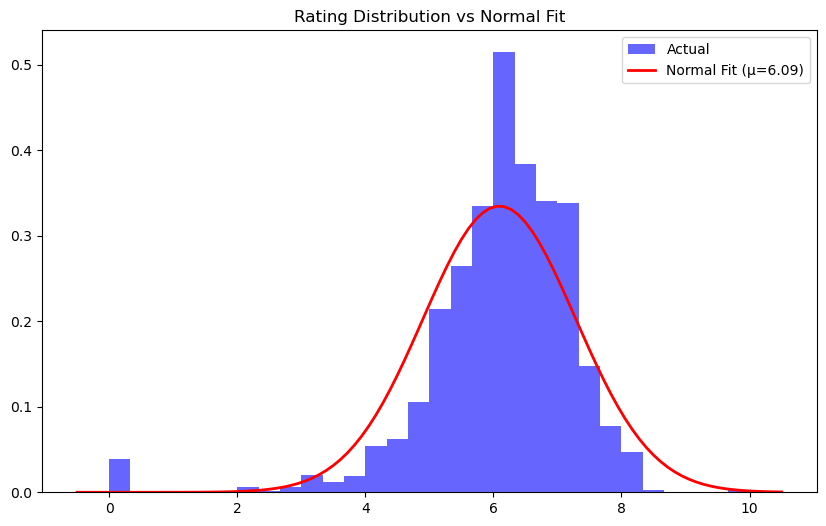

In [119]:
from scipy import stats
from scipy.stats import norm

# Fit normal distribution to ratings
mu, std = norm.fit(movies['rating'])
print(f"Rating ~ Normal(μ={mu:.2f}, σ={std:.2f})")

# Visual comparison
plt.figure(figsize=(10, 6))
plt.hist(movies['rating'], bins=30, density=True, alpha=0.6, color='b', label='Actual')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label=f'Normal Fit (μ={mu:.2f})')
plt.title('Rating Distribution vs Normal Fit')
plt.legend()
plt.show()

### Task 4.2: Probability Calculations

In [120]:
# P(Rating > 7)
prob_above_7 = 1 - norm.cdf(7, mu, std)
print(f"Probability(Rating > 7) = {prob_above_7:.4f} ({prob_above_7*100:.2f}%)")

# Top 10% Rating Threshold
top_10_percentile = norm.ppf(0.90, mu, std)
print(f"Top 10% of movies have a rating above: {top_10_percentile:.2f}")

Probability(Rating > 7) = 0.2233 (22.33%)
Top 10% of movies have a rating above: 7.62


### Task 4.3: Hypothesis Testing

In [121]:
alpha = 0.05
results = []

# Test 1: Action vs Drama Ratings (Independent T-Test)
action = movies[movies['primary_genre'] == 'Action']['rating']
drama = movies[movies['primary_genre'] == 'Drama']['rating']

t_stat, p_val = stats.ttest_ind(action, drama)
conclusion = "Reject H0 (Difference exists)" if p_val < alpha else "Fail to Reject H0"
results.append(['Action vs Drama Ratings', t_stat, p_val, conclusion])

# Test 2: Summer vs Non-Summer Revenue (Independent T-Test, One-Tailed)
# H1: Summer > Other
summer = movies[movies['release_season'] == 'Summer']['revenue']
other = movies[movies['release_season'] != 'Summer']['revenue']
# Log transform to improve normality for t-test validity
t_stat2, p_val2 = stats.ttest_ind(np.log1p(summer), np.log1p(other))
# If t_stat > 0 and p_val/2 < alpha, then significant
p_one_tailed = p_val2 / 2 if t_stat2 > 0 else 1 - (p_val2 / 2)
conclusion2 = "Reject H0 (Summer > Other)" if p_one_tailed < alpha else "Fail to Reject H0"
results.append(['Summer vs Non-Summer Revenue', t_stat2, p_one_tailed, conclusion2])

# Test 3: Genre vs Profitability (Chi-Square Test of Independence)
# Is the likelihood of being profitable dependent on the genre?
contingency = pd.crosstab(movies['primary_genre'], movies['is_profitable'])
chi2, p_val3, dof, expected = stats.chi2_contingency(contingency)
conclusion3 = "Reject H0 (Dependent)" if p_val3 < alpha else "Fail to Reject H0"
results.append(['Genre vs Profitability', chi2, p_val3, conclusion3])

# Test 4: ANOVA (Ratings across Top 5 Genres)
top_5_genres = movies['primary_genre'].value_counts().head(5).index
groups = [movies[movies['primary_genre'] == g]['rating'] for g in top_5_genres]
f_stat, p_val4 = stats.f_oneway(*groups)
conclusion4 = "Reject H0 (Means differ)" if p_val4 < alpha else "Fail to Reject H0"
results.append(['ANOVA (Top 5 Genres Ratings)', f_stat, p_val4, conclusion4])

print("Hypothesis Test Results performed.")

Hypothesis Test Results performed.


### Task 4.4: Summary of Statistical Findings

In [122]:
results_df = pd.DataFrame(results, columns=['Test', 'Statistic', 'P-Value', 'Conclusion'])
display(results_df)

,Test,Statistic,P-Value,Conclusion
0,Action vs Drama Ratings,-9.847109,2.308998e-22,Reject H0 (Difference exists)
1,Summer vs Non-Summer Revenue,4.026506,2.874258e-05,Reject H0 (Summer > Other)
2,Genre vs Profitability,53.558623,6.723698e-05,Reject H0 (Dependent)
3,ANOVA (Top 5 Genres Ratings),59.910387,4.568424e-49,Reject H0 (Means differ)


## Phase 5: PCA & Dimensionality Reduction

### Task 5.1: Data Preparation for PCA

In [123]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select numerical features relevant for structure
# Exclude purely derivative features if we want base structure, or include all.
# Requirement says: budget, revenue, rating, runtime, vote_count, popularity...
pca_features = ['budget', 'revenue', 'rating', 'runtime', 'vote_count', 'vote_average', 'popularity']
# Ensure all exist
pca_features = [c for c in pca_features if c in movies.columns]

X_pca_input = movies[pca_features].dropna()

# Standardize (Critical for PCA)
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_pca_input)

print(f"Data for PCA shape: {X_scaled_pca.shape}")

Data for PCA shape: (4800, 7)


### Task 5.2 & 5.3: Apply PCA & Scree Plot

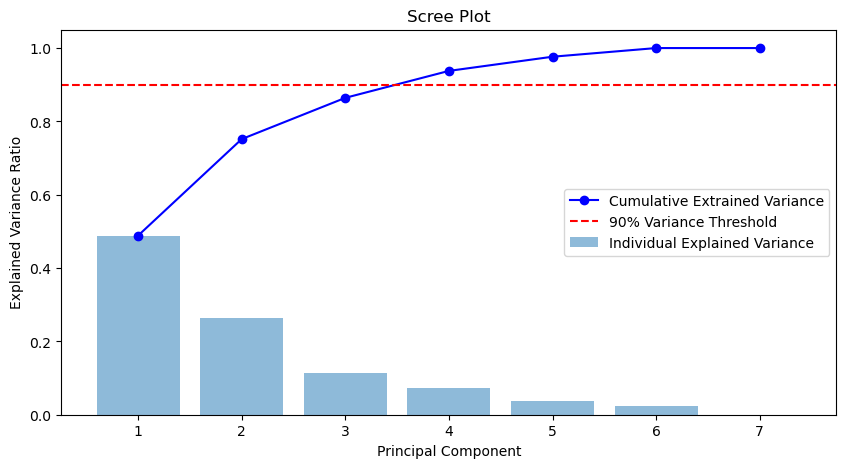

Components needed for 90% variance: 4


In [124]:
pca = PCA()
pca.fit(X_scaled_pca)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Scree Plo00t
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, 'bo-', label='Cumulative Extrained Variance')
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.5, label='Individual Explained Variance')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.legend()
plt.savefig('scree_plot.png')
plt.show()

n_components90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed for 90% variance: {n_components90}")

### Task 5.4 & 5.5: Apply PCA with Optimal Components & Interpretation

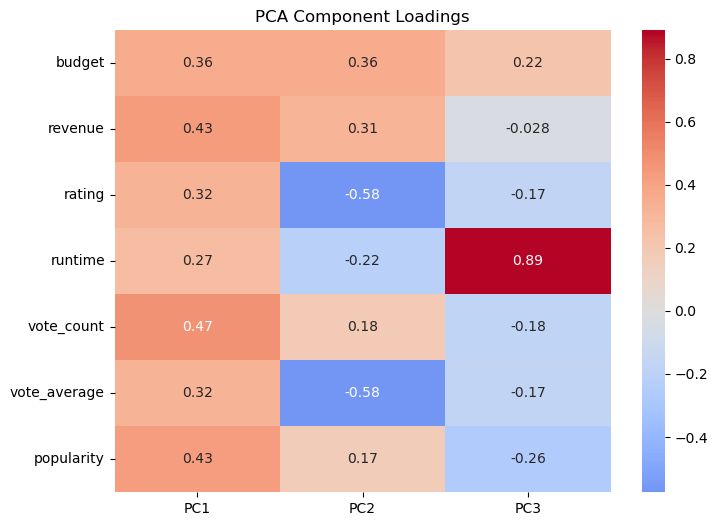

In [125]:
# Use 3 components for visualization potential
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled_pca)

# Loadings Matrix
loadings = pd.DataFrame(
    pca_3.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=pca_features
)

plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0)
plt.title('PCA Component Loadings')
plt.show()

# Interpretation (depends on running code, but generally PC1 is often 'Blockbuster/Size')

### Task 5.6 & 5.7: 2D and 3D Visualization

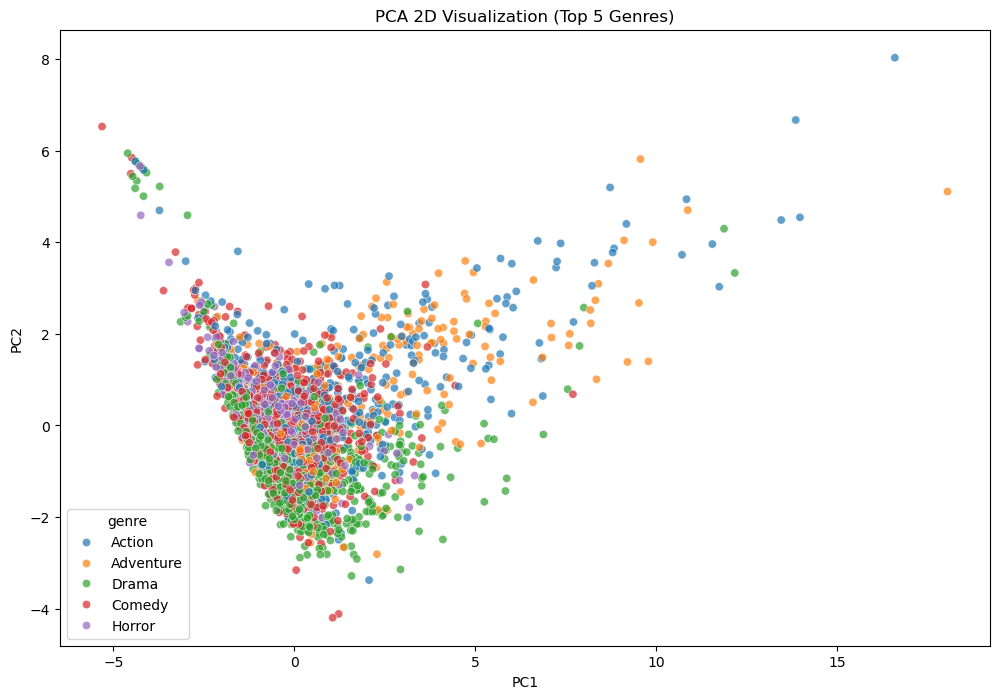

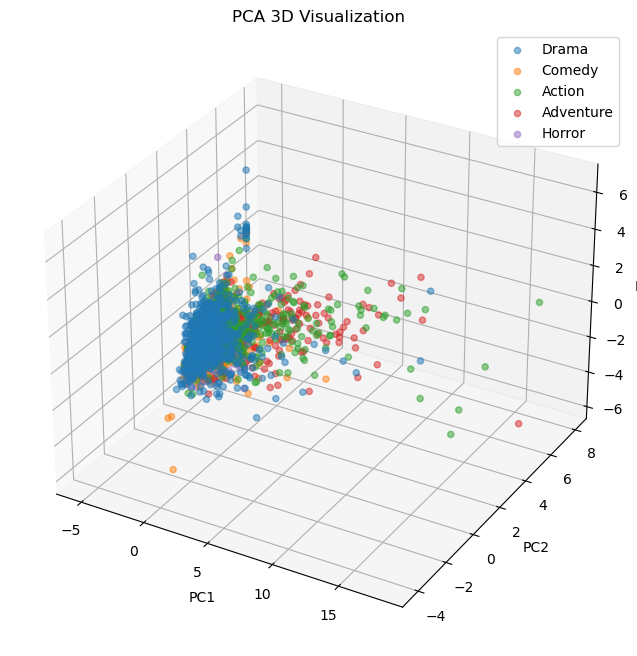

In [126]:
# Create DataFrame for plotting
pca_df = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'], index=X_pca_input.index)
pca_df['genre'] = movies.loc[X_pca_input.index, 'primary_genre']

# 2D Plot
plt.figure(figsize=(12, 8))
# Plot top 5 genres to avoid clutter
top_genres_pca = pca_df['genre'].value_counts().head(5).index
sns.scatterplot(x='PC1', y='PC2', hue='genre', 
                data=pca_df[pca_df['genre'].isin(top_genres_pca)], 
                alpha=0.7)
plt.title('PCA 2D Visualization (Top 5 Genres)')
plt.savefig('pca_2d_visualization.png')
plt.show()

# 3D Plot (Static)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for genre in top_genres_pca:
    mask = pca_df['genre'] == genre
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'], pca_df.loc[mask, 'PC3'], label=genre, alpha=0.5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('PCA 3D Visualization')
plt.legend()
plt.show()

### Task 5.8: Cluster Analysis (K-Means)

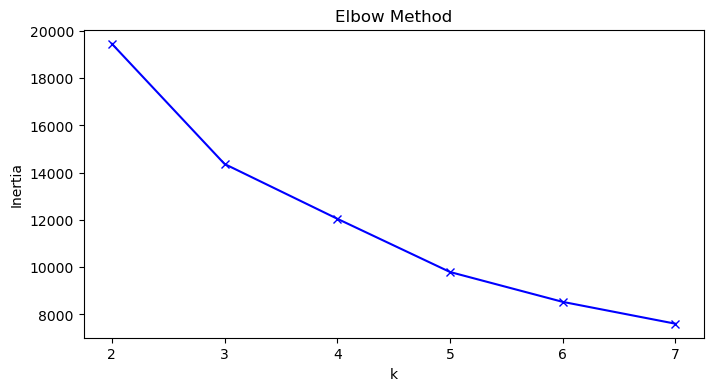

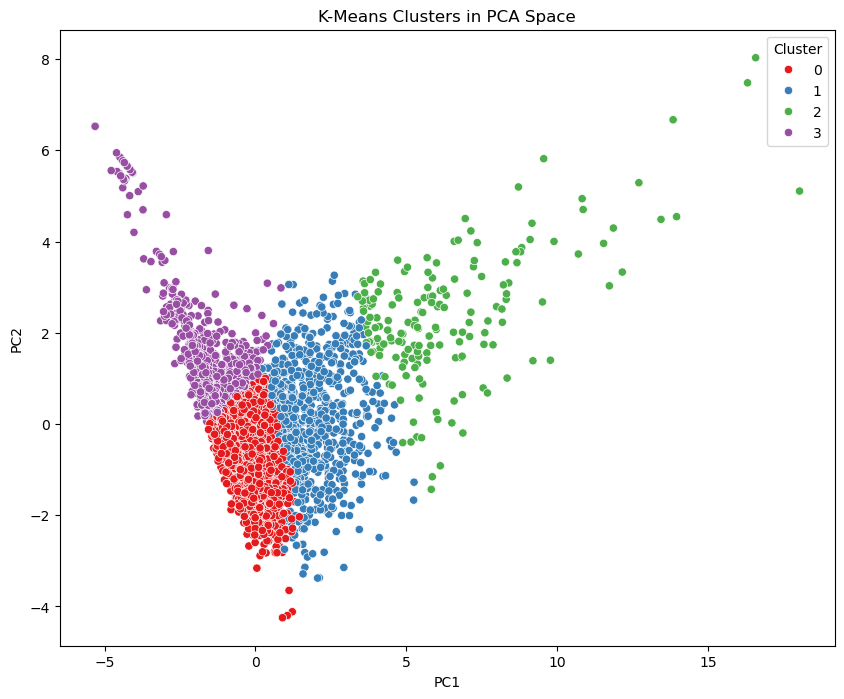

In [127]:
from sklearn.cluster import KMeans

# Elbow method (simplified range)
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca_3)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 8), inertias, 'bx-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.show()

# Apply K-Means with k=4 (Assumption based on typical movie segmentation)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca_3)
pca_df['Cluster'] = clusters

# Visualize Clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', legend='full')
plt.title('K-Means Clusters in PCA Space')
plt.show()

### Task 5.9: Genre Similarity Analysis

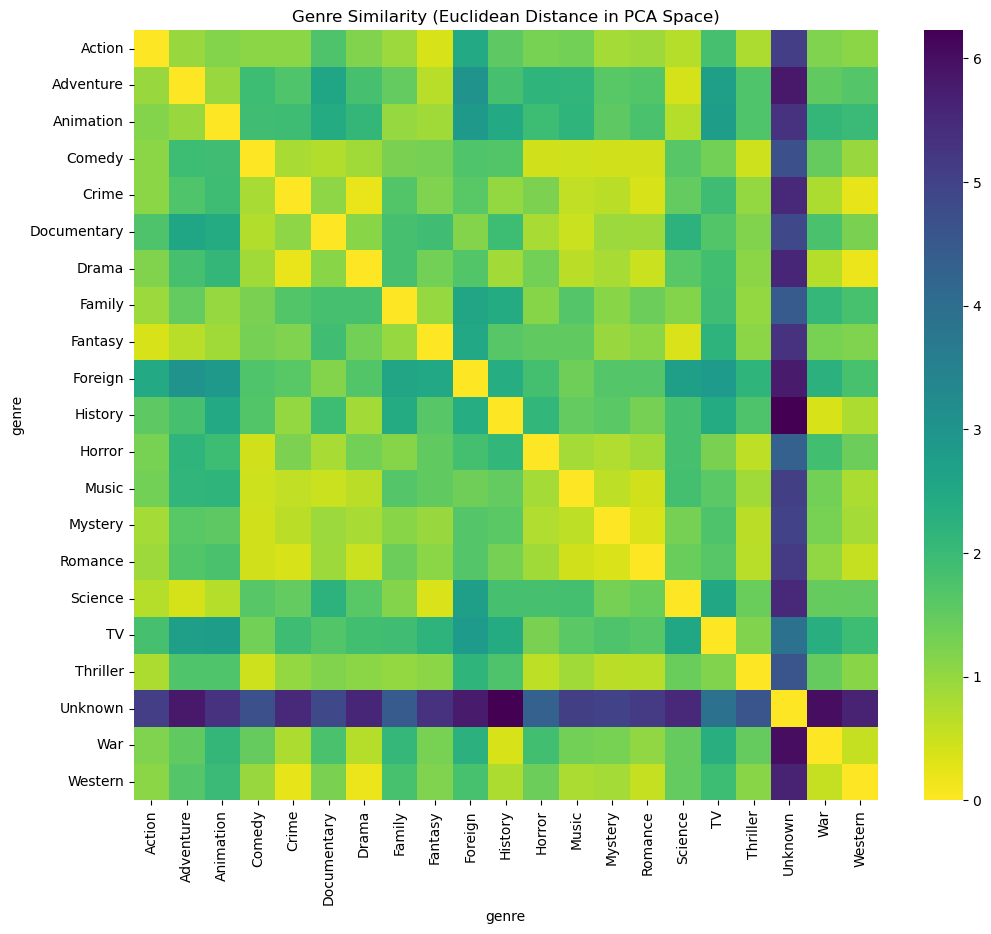

Analysis pipeline complete.


In [128]:
from scipy.spatial.distance import pdist, squareform

# Calculate Centroids of Genres in PCA Space
genre_centroids = pca_df.groupby('genre')[['PC1', 'PC2', 'PC3']].mean()

# Calculate pairwise distance
dists = pdist(genre_centroids.values)
dist_df = pd.DataFrame(
    squareform(dists), 
    columns=genre_centroids.index, 
    index=genre_centroids.index
)

plt.figure(figsize=(12, 10))
sns.heatmap(dist_df, cmap='viridis_r', annot=False) # darker = more similar (closer)
plt.title('Genre Similarity (Euclidean Distance in PCA Space)')
plt.savefig('genre_similarity.png')
plt.show()

print("Analysis pipeline complete.")